# FigGamma1 — Lyman photoionization rate: incident + diffuse closure vs simulation

Decomposition of the ground-state Lyman photoionization rate $\Gamma_{\rm Ly}$ for the
marginally-unbound `dilute_redd` grid ($\dot M = 2.5, 5, 10, 20\,M_\odot$/yr) into an **incident**
and a **diffuse** part, compared to the simulated (Sirocco Monte-Carlo) rate (black).

- **Incident $\Gamma_{\rm Ly}^\star$** (blue, dash-dot): the diluted blackbody actually injected
  at $r_{\rm in}$ (`Central_object.temp`, `T_BB` below; spectral shape frozen under coherent
  Thomson scattering), diluted by the homogeneous ($\kappa=0$) solution of the RT moment ODE
  ($1/r^2$ times the spherical e-scattering trapping integral $W(r)$) and attenuated by the
  sharp-front eikonal depth $\exp[-\int\sqrt{3\kappa_\nu\chi_\nu}\,dr']$ with
  $\kappa_\nu=n_1\sigma_1$, $\chi_\nu=n_1\sigma_1+n_e\sigma_T$ ($\sigma_1=6.30\times10^{-18}$,
  the true threshold value, Milne-consistent with $\alpha_1$).
- **Diffuse $\Gamma_{\rm Ly}^{\rm (d)}=\alpha_1(T_e)\,n_e n_p/n_1$**: on-the-spot direct-to-ground
  recombination continuum. The dotted (orange) curve is the closure total, which overlays the
  simulated rate wherever ionization balance holds (beyond the Lyman break).

Only the simulated $n_1, n_e, n_p, T_e$ enter — there is no statistical-equilibrium solve, and the
incident spectrum is fixed entirely by input-deck quantities. The x-axis is $r/r_{\rm Edd}$; cells
failing more than `CONV_MAX` convergence tests are masked and the m20 outer wind is truncated
(`R_OUT`).

In [1]:
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid as ctz

# ================= config: edit here to point at your data / output =================
# (self-contained per notebook for now; lift this block into a shared repro_paths.py
#  once the final matrix_pow + custom-band reruns exist and dirs are unified.)
DATA_ROOT = os.environ.get("SIROCCO_REPRO_DATA", "/scratch/gpfs/nk6352/sirocco_runs")
FIG_DIR   = os.path.abspath("../figures")           # where this notebook writes its PDF/PNG
RUN_SET   = os.environ.get("SIROCCO_REPRO_RUNSET", "repro")   # "legacy" (paper freeze) | "repro" (repro/ reruns)
# NOTE: repro/ runs = matrix_pow + Photon_sampling=wide (2026-07-24 reruns).
#   Verified 2026-08-11 against the legacy matrix_bb runs: mu_* AND pt_* are healthy
#   (the earlier matrix_pow pt_* under-ionization is gone; e.g. pt_m5 mid-wind h1~6e-4,
#   matching legacy ~5e-4). This figure is mu-only by design.
RUN_DIRS_LEGACY  = {   # NB: the paper-freeze (legacy) grid used Mdot=20 in the last column; keys renamed m15 for plumbing, values untouched
             "m2.5": "1d_m2.5_dilute_redd", "m5":  "1d_m5_dilute_redd",
             "m10":  "1d_m10_dilute_redd",  "m15": "1d_m20_dilute_redd"}
RUN_DIRS_REPRO = {"m2.5": "repro/mu_m2.5", "m5": "repro/mu_m5",
                   "m10": "repro/mu_m10", "m15": "repro/mu_m15"}
RUN_DIRS  = {"legacy": RUN_DIRS_LEGACY, "repro": RUN_DIRS_REPRO}[RUN_SET]
def run_path(k): return os.path.join(DATA_ROOT, RUN_DIRS[k])
os.makedirs(FIG_DIR, exist_ok=True)

# ---- manuscript style ----
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})

# =====================================================================================
# Minimal machinery -- ONLY what Gamma_1 needs.  The level solve / break finder are
# deliberately omitted; we take n_1(r) straight from Sirocco and just attenuate the
# incident Lyman continuum.  Diffuse part = alpha_1 n_e n_p / n_1 (on-the-spot closure):
# in photoionization equilibrium Gamma_1 n_1 = alpha_1 n_e n_p, so this must lock onto
# Sirocco's Gamma_1 wherever the gas is in ionization balance -- i.e. BEYOND the Lyman break.
# =====================================================================================
C=2.998e10; H=6.6261e-27; KB=1.3807e-16; M_P=1.6726e-24; S_T=6.65e-25; X_H=0.71
G=6.674e-8; MSUN=1.989e33; MBH=1e6*MSUN
SIG1=6.30e-18; NU1=C/912e-8                        # H I ground-state edge x-section (true threshold value = Kramers 7.907e-18 x Gaunt 0.797; matches Sirocco's atomic data + Milne-consistent with alpha_1), Lyman edge freq
L_EDD=1.4393e44; SB=5.6704e-5                       # L radiated (fixed) and Stefan-Boltzmann
R_EDD=lambda Mdot: 3.2e14*Mdot                      # Eddington radius = wind base R_in(Mdot)
nuLy=np.logspace(np.log10(NU1),np.log10(NU1)+0.9,24); sigLy=SIG1*(NU1/nuLy)**3   # Lyman band grid

# Incident color temperature per run == Central_object.temp actually input in the .pf files
# (Central_object.dilution_factor = L_Edd / 4 pi r_in^2 sigma T^4, verified against the pf values).
# Under coherent Thomson scattering the incident component's spectral SHAPE is frozen at the input,
# so the incident field keeps this color everywhere; reddening of the total field is carried by the
# diffuse component. (These input temps were chosen at setup from the grey-diffusion relation
# T_eff*[3/4(tau_es+2/3)]^{1/4} with the analytic fully-ionized column; recomputing tau_es from the
# simulated n_e gives ~4-9% cooler and is NOT the incident spectrum -- do not do that.)
T_BB = {"m2.5": 49426.0, "m5": 38112.0, "m10": 29389.0, "m15": 25243.0}   # last column = mu_m15 (T_color from its pf)

def aA(T): return 4.18e-13*(T/1e4)**-0.721          # Case-A total recombination coeff [cm^3/s]
def aB(T): return 2.59e-13*(T/1e4)**-0.833          # Case-B recombination coeff [cm^3/s]
def a1(T): return aA(T)-aB(T)                        # recombination DIRECT to ground state n=1

def planck(nu,T):
    "Planck function B_nu(T)."
    return 2*H*nu**3/C**2/np.expm1(np.minimum(H*nu/(KB*T),700))

def simGamma(J,fr,Nc,thr,sig0,e0):
    "Sirocco's actual Gamma from the per-cell MC field J_nu."
    s=fr>=thr; nu=fr[s]; sig=sig0*(e0/nu)**3; out=np.zeros(Nc); nn=min(Nc,J.shape[0])
    out[:nn]=np.trapz((4*np.pi*J[:nn][:,s]/(H*nu))*sig,nu,axis=1); return out

def incident_field(r,ne,T_in):
    "Dilution W(r) of the incident continuum: input diluted BB at T_in carrying L = L_Edd."
    g=ne*S_T/r**2; enh=np.maximum(0.75*r**2*(np.trapz(g,r)-ctz(g,r,initial=0)),1.0)   # trapping boost
    W=L_EDD/(4*np.pi*r**2*SB*T_in**4)*enh          # geometric dilution x spherical e-scatt trapping
    return W,T_in

def load_run(run_dir):
    "Structure (r, ne, converge, Te, n_p) + Sirocco's n_1(r) and its actual Gamma_1, inwind cells only."
    m=pd.read_csv(f'{run_dir}/outflow.master.txt',sep=r'\s+');     m=m[m['inwind']==0].reset_index(drop=True)
    L=pd.read_csv(f'{run_dir}/outflow.H_1.levden.txt',sep=r'\s+'); L=L[L['inwind']==0].reset_index(drop=True)
    x=pd.read_csv(sorted(glob.glob(f'{run_dir}/outflow.xspec.all*.txt'))[0],sep=r'\s+')
    fr=x['Freq.'].values; cols=[c for c in x.columns if c!='Freq.' and c.startswith('F')]; J=x[cols].values.T
    r=m['r'].values; ne=m['ne'].values; conv=m['converge'].values
    Te=m['t_e'].values; nH=m['rho'].values*X_H/M_P; npr=(1.0-m['h1'].values)*nH   # proton density n_p = n(H II)
    n1=(L['ion_den']*L['lev1']).values
    G1sim=simGamma(J,fr,len(r),NU1,SIG1,NU1)
    return r,ne,conv,n1,G1sim,Te,npr

def gamma1_recomb(Te,ne,npr,n1):
    "Recombination-balance Gamma_1 = alpha_1(Te) n_e n_p / n_1 (== Gamma_1 in ioniz. equilibrium)."
    return a1(Te)*ne*npr/n1

RUNS=[('2.5','m2.5',2.5), ('5','m5',5.0), ('10','m10',10.0), ('15','m15',15.0)]

In [2]:
# =====================================================================================
# Gamma_1^star : INCIDENT (stellar) Lyman-continuum photoionization rate.
#   Incident continuum = the diluted blackbody actually input at r_in (Central_object.temp,
#   shape frozen under coherent Thomson scattering), diluted by the HOMOGENEOUS (kappa=0)
#   solution of the RT moment ODE (1/r^2 x spherical e-scatt trapping; W from incident_field),
#   attenuated by the eikonal absorption depth of the sharp-front solution:
#       4pi J_nu(r) = 4pi W(r) B_nu(T_BB) * exp( -INT_{r0}^{r} sqrt(3 kappa chi) dr' )
#       kappa_nu = n1 sig1(nu)             (true bf absorption / sink)
#       chi_nu   = n1 sig1(nu) + ne sigT   (total extinction; e-scattering slows diffusion)
#   The local boundary factor sqrt(3 chi/kappa) and WKB amplitude (chi/kappa)^(1/4) are DROPPED:
#   both diverge as kappa -> 0 in the ionized base (pure-scattering limit) where that boundary
#   relation is invalid; the physical e-scatt trapping there is carried by W(r) instead.
#   Gamma_1^star = INT 4pi J_nu sig1(nu)/(h nu) dnu.
# =====================================================================================
def gamma1_star(key, r, ne, n1):
    "Incident Gamma_1^star: homogeneous-diffusion dilution W(r) x eikonal LyC attenuation."
    W, T_in = incident_field(r, ne, T_BB[key])                     # 1/r^2 x spherical e-scatt trapping; input BB color
    B_Ly = planck(nuLy, T_in)
    kap = n1[:, None]*sigLy[None, :]                               # kappa_nu(r)  (Nc,Nnu)
    chi = kap + (ne*S_T)[:, None]                                  # chi_nu(r)
    tau = ctz(np.sqrt(3.0*kap*chi), r, axis=0, initial=0.0)        # INT_r0^r sqrt(3 kap chi) dr'  (eikonal)
    fourpiJ = (4*np.pi*W)[:, None]*B_Ly[None, :]*np.exp(-tau)      # 4pi J_nu(r)  (Nc,Nnu)
    return np.trapz(fourpiJ*sigLy[None, :]/(H*nuLy[None, :]), nuLy, axis=1)

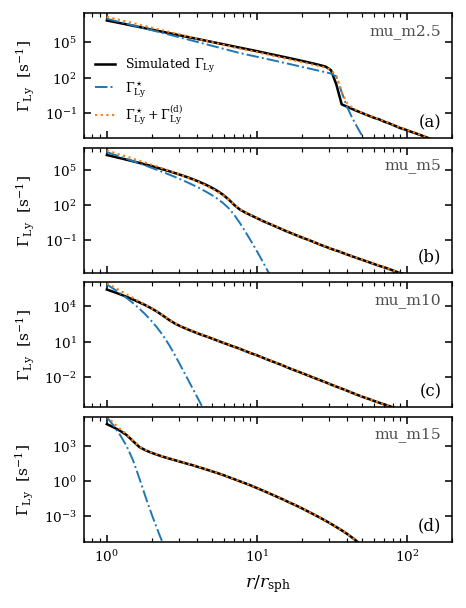

In [3]:
# ---- one short single-column panel per run; share x; mask only poorly-converged cells ----
# Sirocco's `converge` counts how many of the 3 tests (t_e, t_r, heating/cooling) a cell failed
# (0 = all pass). Blank only cells failing MORE than CONV_MAX tests, so marginally-converged cells
# (one test off) are kept. x-axis is r / r_Edd, r_Edd = R_EDD(Mdot) = 3.2e14*Mdot = wind base r[0].
# R_OUT caps the outer radius per run: m15 has stray converged cells far out (artifacts of the
# poorly-converged outer wind) -- cut them so panel (d) shows only the clean inner solution.
#   Curves:  Gamma_1 (Sirocco, black); Gamma_1^star (incident, blue, dash-dot);
#            Gamma_1^star + Gamma_1^(d) closure total (orange, dotted).
CONV_MAX = 2
R_OUT = {'20': 2.0e17}                               # per-run outer cutoff [cm]; default below
C_SIM, C_INC, C_TOT = 'k', 'tab:blue', 'tab:orange'
fig, axes = plt.subplots(len(RUNS), 1, figsize=(3.4, 4.9), sharex=True,
                         gridspec_kw=dict(hspace=0.08))
letters = iter('abcd')
for ax, (lab, key, Mdot) in zip(axes, RUNS):
    r, ne, conv, n1, G1sim, Te, npr = load_run(run_path(key))
    G1s   = gamma1_star(key, r, ne, n1)             # incident: input diluted BB x W(r) x eikonal atten.
    G1d   = gamma1_recomb(Te, ne, npr, n1)          # diffuse: on-the-spot direct-to-ground recomb continuum
    G1tot = G1s + G1d                               # closure total = incident + diffuse
    rE    = R_EDD(Mdot); x = r/rE                   # r_Edd = 3.2e14*Mdot cm; plot r/r_Edd

    # last acceptably-converged cell within the per-run outer cutoff; blank poorly-converged cells within
    ok   = np.where(conv <= CONV_MAX)[0]
    sel  = ok[ok < np.searchsorted(r, R_OUT.get(lab, 1.2e18))]
    rmax = r[sel[-1]] if len(sel) else r[0]
    msk  = r <= rmax
    cmask = lambda a: np.where(conv[msk] <= CONV_MAX, a[msk], np.nan)

    ax.loglog(x[msk], cmask(G1sim),  color=C_SIM, lw=1.3,           label=r'Simulated $\Gamma_{\rm Ly}$')
    ax.loglog(x[msk], cmask(G1s),    color=C_INC, lw=1.0, ls='-.',  label=r'$\Gamma_{\rm Ly}^\star$')
    ax.loglog(x[msk], cmask(G1tot),  color=C_TOT, lw=1.1, ls=':',   label=r'$\Gamma_{\rm Ly}^\star+\Gamma_{\rm Ly}^{\rm (d)}$')
    top = np.nanmax(cmask(G1sim)); ax.set_ylim(top/1e10, top*4)     # ~6 decades; LyC underflow runs off-panel
    ax.set_ylabel(r'$\Gamma_{\rm Ly}$  [s$^{-1}$]', fontsize=8)
    ax.tick_params(which='both', labelsize=7)
    ax.text(0.97, 0.06, f'({next(letters)})', transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5)
    ax.text(0.97, 0.92, f'mu_m{lab}',         transform=ax.transAxes, ha='right', va='top',    fontsize=8, color='0.30')

axes[0].legend(frameon=False, fontsize=6.5, loc='lower left', handlelength=1.6, labelspacing=0.3)
axes[-1].set_xlabel(r'$r/r_{\rm sph}$', fontsize=9)
axes[0].set_xlim(0.7, 2e2)
fig.savefig(os.path.join(FIG_DIR, 'FigGamma1.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'FigGamma1.png'), dpi=300)
plt.show()